In [ ]:
import numpy as np
import pandas as pd
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn import preprocessing

In [ ]:
data = pd.read_csv('Road.csv')

In [ ]:
data.shape

(12316, 32)

In [ ]:
data.describe()

,Number_of_vehicles_involved,Number_of_casualties
count,12316.000000,12316.000000
mean,2.040679,1.548149
std,0.688790,1.007179
min,1.000000,1.000000
25%,2.000000,1.000000
50%,2.000000,1.000000
75%,2.000000,2.000000
max,7.000000,8.000000


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Time                         12316 non-null  object
 1   Day_of_week                  12316 non-null  object
 2   Age_band_of_driver           12316 non-null  object
 3   Sex_of_driver                12316 non-null  object
 4   Educational_level            11575 non-null  object
 5   Vehicle_driver_relation      11737 non-null  object
 6   Driving_experience           11487 non-null  object
 7   Type_of_vehicle              11366 non-null  object
 8   Owner_of_vehicle             11834 non-null  object
 9   Service_year_of_vehicle      8388 non-null   object
 10  Defect_of_vehicle            7889 non-null   object
 11  Area_accident_occured        12077 non-null  object
 12  Lanes_or_Medians             11931 non-null  object
 13  Road_allignment              12

In [ ]:
data.columns

Index(['Time', 'Day_of_week', 'Age_band_of_driver', 'Sex_of_driver',
       'Educational_level', 'Vehicle_driver_relation', 'Driving_experience',
       'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle',
       'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians',
       'Road_allignment', 'Types_of_Junction', 'Road_surface_type',
       'Road_surface_conditions', 'Light_conditions', 'Weather_conditions',
       'Type_of_collision', 'Number_of_vehicles_involved',
       'Number_of_casualties', 'Vehicle_movement', 'Casualty_class',
       'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity',
       'Work_of_casuality', 'Fitness_of_casuality', 'Pedestrian_movement',
       'Cause_of_accident', 'Accident_severity'],
      dtype='object')

In [ ]:
data.dropna(inplace=True)

In [ ]:
data['Age_band_of_driver'].unique()
data['Casualty_severity'].unique()
data['Driving_experience'].unique()
data['Pedestrian_movement'].unique()
data['Cause_of_accident'].unique()
data['Time']

,Time
8,17:20:00
9,17:20:00
12,17:45:00
13,17:45:00
14,17:45:00
...,...
12302,17:25:00
12303,12:48:00
12313,13:55:00
12314,13:55:00


In [ ]:
#Modifying Time to required format
data['Time'] = pd.to_datetime(data['Time'], format='%H:%M:%S')
data['hour'] = data['Time'].dt.hour
data['minute'] = data['Time'].dt.minute

In [ ]:
data = data.drop(['Time','Educational_level','Vehicle_driver_relation','Owner_of_vehicle','Service_year_of_vehicle','Number_of_casualties','Work_of_casuality'],axis = 1)

In [ ]:
def label_encode_columns(data, columns_to_encode):
    label_encoder = preprocessing.LabelEncoder()
    for column in columns_to_encode:
        data[column] = label_encoder.fit_transform(data[column])

columns_to_encode = [
    'Day_of_week', 'Age_band_of_driver', 'Sex_of_driver', 'Driving_experience',
    'Type_of_vehicle', 'Defect_of_vehicle', 'Area_accident_occured',
    'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction',
    'Road_surface_type', 'Road_surface_conditions', 'Light_conditions',
    'Weather_conditions', 'Type_of_collision', 'Number_of_vehicles_involved',
    'Vehicle_movement', 'Casualty_class', 'Sex_of_casualty',
    'Age_band_of_casualty', 'Casualty_severity', 'Fitness_of_casuality',
    'Pedestrian_movement', 'Cause_of_accident', 'Accident_severity'
]

label_encode_columns(data, columns_to_encode)

In [ ]:
data.head()

,Day_of_week,Age_band_of_driver,Sex_of_driver,Driving_experience,Type_of_vehicle,Defect_of_vehicle,Area_accident_occured,Lanes_or_Medians,Road_allignment,Types_of_Junction,...,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity,hour,minute
8,0,0,1,3,5,2,4,6,4,7,...,2,1,4,2,2,0,1,2,17,20
9,0,0,1,0,0,2,8,4,4,7,...,1,1,0,2,2,5,9,1,17,20
12,4,0,1,0,11,2,6,0,0,1,...,3,2,5,3,2,5,10,2,17,45
13,4,1,1,2,5,2,6,6,4,1,...,3,2,5,3,2,5,12,2,17,45
14,4,1,1,3,0,2,6,4,0,1,...,0,0,0,2,2,5,10,1,17,45


<Axes: >

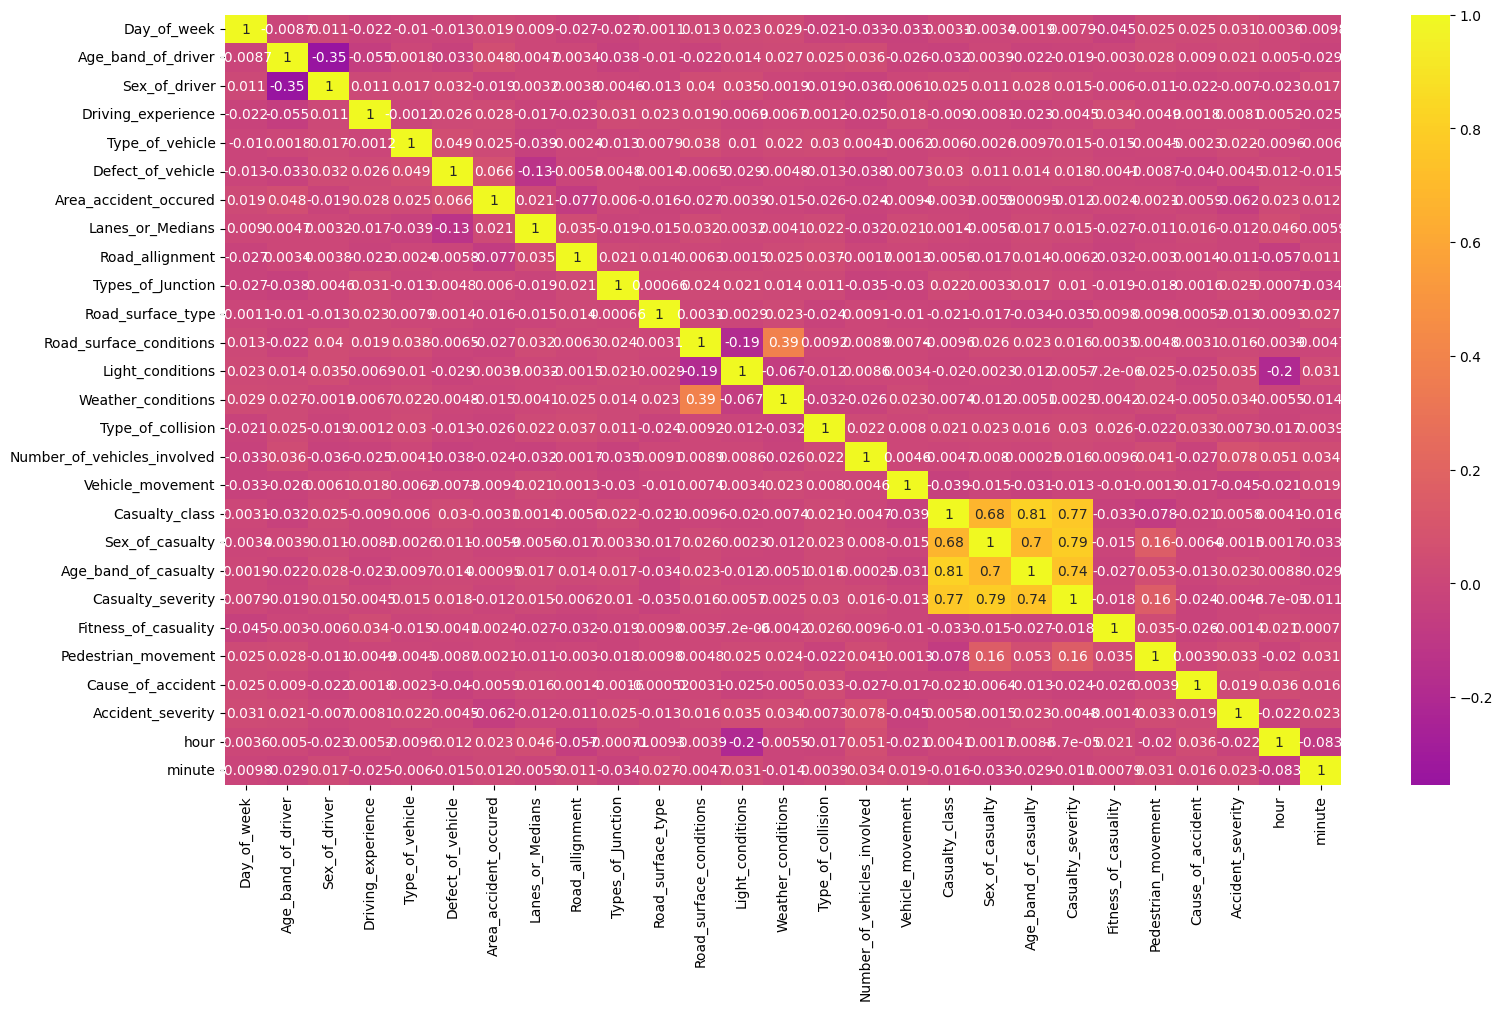

In [ ]:
corr_matrix=data.corr()
plt.figure(1, figsize=(18,10))
sns.heatmap(corr_matrix, cmap='plasma', center=0, annot=True)

In [ ]:
X = data.drop(['Accident_severity'],axis =1)
Y = data['Accident_severity']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.15, random_state=13)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
RForest_clf = RandomForestClassifier(n_estimators = 100)
RForest_clf.fit(X_train, y_train)
y_pred = RForest_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)*100
print(f'Accuracy: {accuracy}')

Accuracy: 85.71428571428571


In [ ]:
import xgboost as xgb
xgb_classifier = xgb.XGBClassifier()
xgb_classifier.fit(X_train,y_train)
y_pred = xgb_classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)*100
print(f'Accuracy: {accuracy}')

Accuracy: 85.02304147465438


In [ ]:
from sklearn.svm import SVC
model = SVC()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)*100
print(f'Accuracy: {accuracy}')

Accuracy: 85.71428571428571


In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)*100
print(f'Accuracy: {accuracy}')

Accuracy: 85.71428571428571


In [ ]:
from sklearn import tree
clf = tree.DecisionTreeClassifier()
clf = clf.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)*100
print(f'Accuracy: {accuracy}')

Accuracy: 85.71428571428571


Accuracy for Logistic Regression: 0.86
Accuracy for KNeighbors Classifier: 0.77
Accuracy for Random Forest: 0.86
Accuracy for Support Vector Machine: 0.86
Accuracy for XGBoost: 0.85


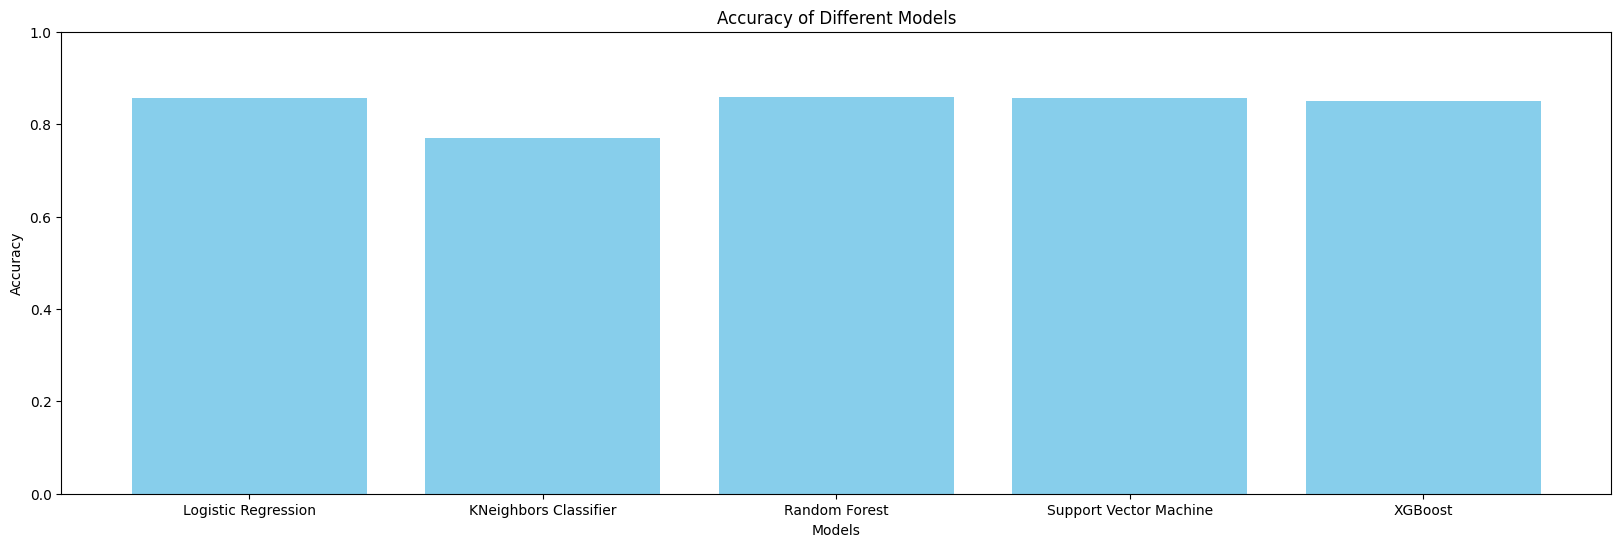

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(),
    'KNeighbors Classifier': tree.DecisionTreeClassifier(),
    'Random Forest' :  RandomForestClassifier(),
    'Support Vector Machine' : SVC(),
    'XGBoost' : xgb.XGBClassifier()
}

accuracies = []

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)
    print(f'Accuracy for {model_name}: {accuracy:.2f}')

# Create a bar plot for the accuracies
plt.figure(figsize=(20, 6))
plt.bar(models.keys(), accuracies, color='skyblue')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Accuracy of Different Models')
plt.ylim([0, 1])
plt.show()

In [ ]:
import zipfile
import os

zip_path = "archive (4).zip"   # upload the zip to Colab
extract_path = "dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted!")

Dataset extracted!


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
img_size = 128
batch_size = 32

train_dir = "dataset/data/train"
test_dir = "dataset/data/test"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical'
)

Found 791 images belonging to 2 classes.
Found 100 images belonging to 2 classes.


In [ ]:
cnn_model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(img_size,img_size,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(train_generator.num_classes, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,898 (12.61 MB)

 Trainable params: 3,304,898 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = cnn_model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=10
)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.5230 - loss: 0.7244 - val_accuracy: 0.5300 - val_loss: 0.6911
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.5213 - loss: 0.6913 - val_accuracy: 0.5300 - val_loss: 0.6865
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.5646 - loss: 0.6862 - val_accuracy: 0.5000 - val_loss: 0.6927
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.5524 - loss: 0.6864 - val_accuracy: 0.4900 - val_loss: 0.7227
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.5870 - loss: 0.6795 - val_accuracy: 0.5000 - val_loss: 0.6904
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.5835 - loss: 0.6756 - val_accuracy: 0.5300 - val_loss: 0.7107
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.6284 - loss: 0.6500 - val_accuracy: 0.6200 - val_loss: 0.6617
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.6253 - loss: 0.6437 - val_accuracy: 0.6000 - val_loss:

Accuracy for Logistic Regression: 0.86
Accuracy for KNeighbors Classifier: 0.78
Accuracy for Random Forest: 0.86
Accuracy for Support Vector Machine: 0.86
Accuracy for XGBoost: 0.85
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 379ms/step - accuracy: 0.6416 - loss: 0.6058
Accuracy for CNN: 0.63


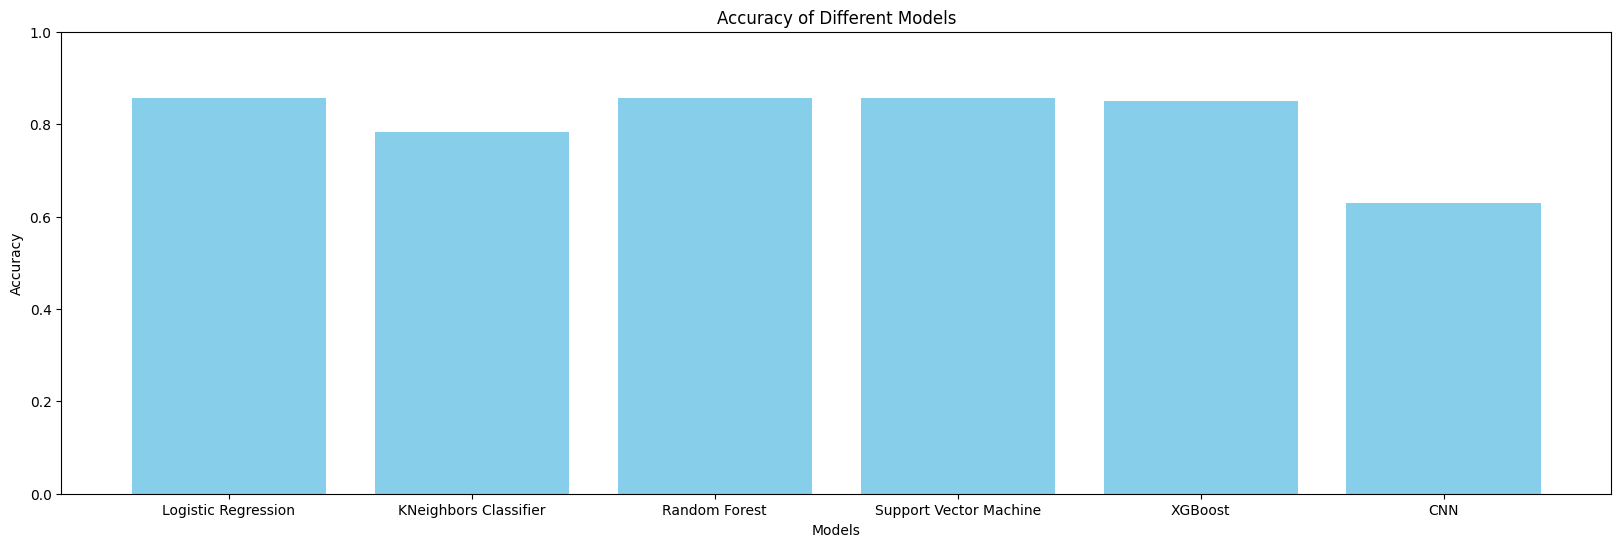

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(),
    'KNeighbors Classifier': tree.DecisionTreeClassifier(),
    'Random Forest' :  RandomForestClassifier(),
    'Support Vector Machine' : SVC(),
    'XGBoost' : xgb.XGBClassifier()
}

accuracies = []
model_names = []

# Train traditional ML models
for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    accuracies.append(accuracy)
    model_names.append(model_name)

    print(f'Accuracy for {model_name}: {accuracy:.2f}')

# ---------------- CNN PART ----------------
# CNN is trained separately

cnn_loss, cnn_accuracy = cnn_model.evaluate(test_generator)

accuracies.append(cnn_accuracy)
model_names.append("CNN")

print(f'Accuracy for CNN: {cnn_accuracy:.2f}')

# ---------------- PLOT ----------------

plt.figure(figsize=(20, 6))
plt.bar(model_names, accuracies, color='skyblue')

plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Accuracy of Different Models')
plt.ylim([0, 1])

plt.show()